In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [3]:
widthD = 30

X, Y = widthD, 30
lattice = Lattice(X, Y)

t = 1
T = 0.01

muD = 0.50 * t
mu = np.ones(lattice.X) * muD

U = None
V_prime = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)

In [4]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V, g_t=None,
                F_init=[0.5, 0.5, -0.5, -0.5])

In [5]:
bdg_sc(H, atol=1e-6, rtol=0.001, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.07425037422576539
Relative error: 74250374225.7654
Average old: 0j
Average: (0.010259964647494811+0j)
F_xplus:
Absolute error: 0.9474704440309165
Relative error: 1.8949408880580432
Average old: (0.5+0j)
Average: (0.3244675465588417+0j)
F_xmin:
Absolute error: 0.9869210055731887
Relative error: 326312828929.4521
Average old: (0.48275862068965514+0j)
Average: (0.32446754655884175+0j)
F_yplus:
Absolute error: 0.924207296854776
Relative error: 108803083731.79147
Average old: (-0.48333333333333334+0j)
Average: (-0.32237305852121373-2.1014139020712903e-16j)
F_ymin:
Absolute error: 0.924207296854776
Relative error: 108803083731.79147
Average old: (-0.48333333333333334+0j)
Average: (-0.32237305852121373+2.1014139020712903e-16j)
Fuu_xplus:
Absolute error: 3.250066173515529e-16
Relative error: 0.00032500661735155293
Average old: 0j
Average: (-4.5007026938060625e-17+0j)
Fuu_xmin:
Absolute error: 2.6188879664586517e-16
Relative error: 0.00026188879664586516
Average old: 0j
Av

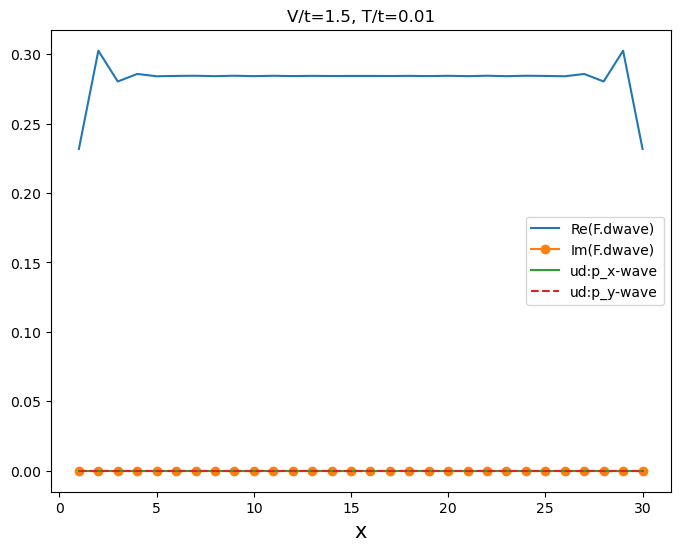

In [6]:
x = np.arange(1, widthD + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [14]:
from scripts.utils import is_hermitian

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))

True
True
True


In [7]:
print(F.dwave[X//2])

(0.2843383125738074+0j)


In [8]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.61 + 1e-12, 0.01)
])  # 109 temps total
print(len(temps))

70


In [9]:
width = 30
X, Y = width, 30
lattice = Lattice(X, Y)

t = 1
T = 0.01

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

U = None
V_prime = None

V0 = 2 * t
V = V0 * np.ones(lattice.X)
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V, g_t=None,
                F_init=[0.1, -0.1, 0.1j, -0.1j])


In [10]:
from scripts.utils import is_hermitian

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))


True
True
True


In [11]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.034907181414193716
Relative error: 34907181414.19372
Average old: 0j
Average: (-0.003833122993754511+0j)
F_xplus:
Absolute error: 0.5205848730827141
Relative error: 5.205848730775081
Average old: (0.09999999999999999+0j)
Average: (0.004094316349637764+0j)
F_xmin:
Absolute error: 0.5431518591476217
Relative error: 67443688214.12887
Average old: (-0.09655172413793103+0j)
Average: (0.004094316349637767+0j)
F_yplus:
Absolute error: 0.538535496225294
Relative error: 513266504.29081076
Average old: 0.09666666666666666j
Average: (0.0006575886403989817+4.765353559245688e-18j)
F_ymin:
Absolute error: 0.538535496225294
Relative error: 513266504.29081076
Average old: -0.09666666666666666j
Average: (0.0006575886403989817-4.765353559245688e-18j)
Fuu_xplus:
Absolute error: 1.1053237383334145e-16
Relative error: 0.00011053237383334144
Average old: 0j
Average: (2.027867350997431e-18+0j)
Fuu_xmin:
Absolute error: 1.0884606515547853e-16
Relative error: 0.00010884606515547853
Averag

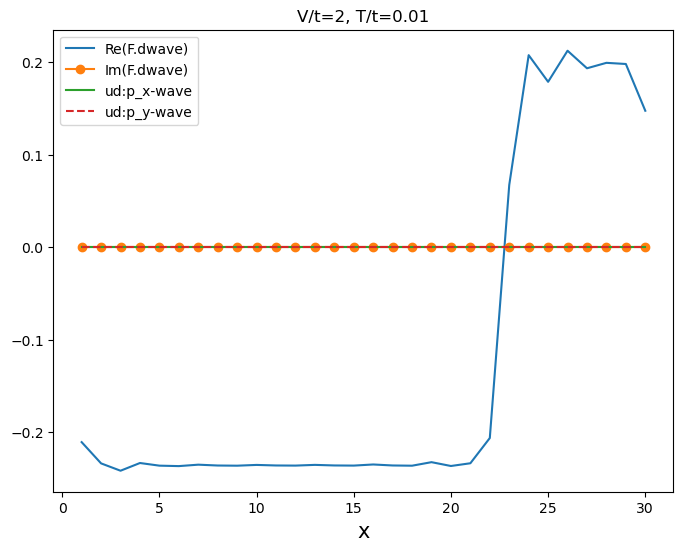

In [12]:
x = np.arange(1, width + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [13]:
print(F.py[X//2])
print(F.px[X//2])


-6.704706234650358e-17j
(4.163336342344337e-17+0j)
